<a id="1"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🎓 Student GPA Regression Analysis and Prediction
</h2>

This project predicts a student's **GPA**, which is a continuous numerical value. Therefore, the problem is treated as a **regression problem**. The same Student Performance dataset is used, with `GPA` as the target variable.


<a id="2"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📚 Importing Required Libraries
</h2>

The required Python libraries are imported for data handling, visualization, preprocessing, regression modeling, evaluation, and model saving.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


<a id="4"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📂 Loading the Dataset
</h2>

The Student Performance dataset is loaded using Pandas. It contains student demographic, academic, study, and activity information.


In [3]:
df = pd.read_csv(r"C:\Users\sahit\OneDrive\Desktop\AICW 2.0\miniprojectclassification and regression\Student_performance_data _.csv")
df.head()


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


<a id="6"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🔎 Understanding the Dataset
</h2>

This step checks the shape, column names, data types, and basic information of the dataset. Understanding the data helps identify the target variable and the features used for prediction.


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nDataset Information:")
df.info()


Shape: (2392, 15)

Columns:
['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']

Data Types:
StudentID              int64
Age                    int64
Gender                 int64
Ethnicity              int64
ParentalEducation      int64
StudyTimeWeekly      float64
Absences               int64
Tutoring               int64
ParentalSupport        int64
Extracurricular        int64
Sports                 int64
Music                  int64
Volunteering           int64
GPA                  float64
GradeClass           float64
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-nu

<a id="8"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📊 Statistical Description
</h2>

`describe()` provides important statistical measures such as count, mean, standard deviation, minimum, quartiles, and maximum for numerical columns.


In [5]:
df.describe()


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


<a id="10"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🧹 Data Cleaning and Preprocessing
</h2>

For GPA regression, `StudentID` is removed because it is only an identifier. `GradeClass` is also removed because it is derived from GPA and would cause target leakage. Missing values and duplicate rows are checked before modeling.


In [6]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop(columns=["StudentID", "GradeClass"], errors="ignore")
df = df.dropna().drop_duplicates()

print("\nShape after preprocessing:", df.shape)


Missing values:
StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

Duplicate rows: 0

Shape after preprocessing: (2392, 13)


<a id="12"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🎯 Selecting Features and Target
</h2>

`GPA` is the target variable because it is a continuous numerical value. All remaining columns are used as input features.


In [7]:
X = df.drop("GPA", axis=1)
y = df["GPA"]

print("Features:")
print(X.columns.tolist())
print("\nTarget: GPA")


Features:
['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering']

Target: GPA


<a id="14"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
✂️ Train-Test Split
</h2>

The dataset is divided into training and testing sets. The training set is used to learn patterns, while the test set is used to evaluate how well the model predicts unseen students.


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=101
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (1674, 12)
Testing data: (718, 12)


<a id="16"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
⚖️ Feature Scaling
</h2>

StandardScaler transforms numerical features to a common scale. Scaling is especially useful for distance-based and regularized regression models such as KNN, SVR, Ridge, Lasso, and ElasticNet. The scaler is fitted only on training data to avoid data leakage.


In [9]:
scaler = StandardScaler()

X_train_fit = scaler.fit_transform(X_train)
X_test_fit = scaler.transform(X_test)


<a id="18"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📈 GPA Distribution
</h2>

A histogram is used to visualize how GPA values are distributed in the dataset.


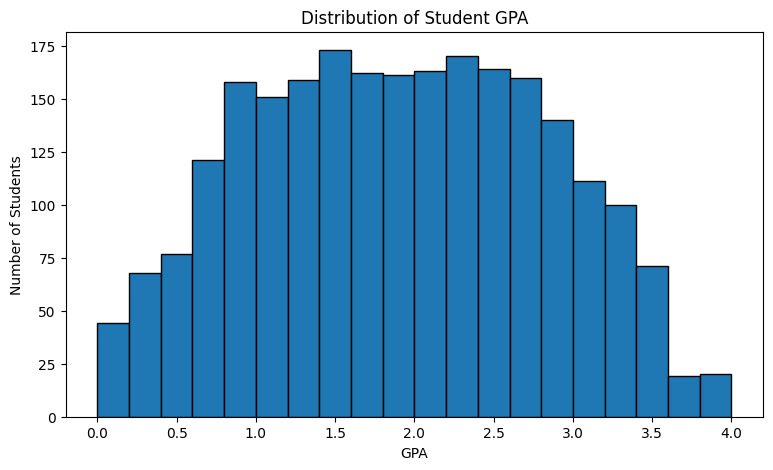

In [10]:
plt.figure(figsize=(9, 5))
plt.hist(y, bins=20, edgecolor="black")
plt.xlabel("GPA")
plt.ylabel("Number of Students")
plt.title("Distribution of Student GPA")
plt.show()


<a id="20"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🔗 Correlation Analysis
</h2>

A correlation heatmap is used to understand the relationships between numerical variables and GPA. Correlation values close to +1 or -1 indicate stronger linear relationships, while values close to 0 indicate weaker linear relationships.


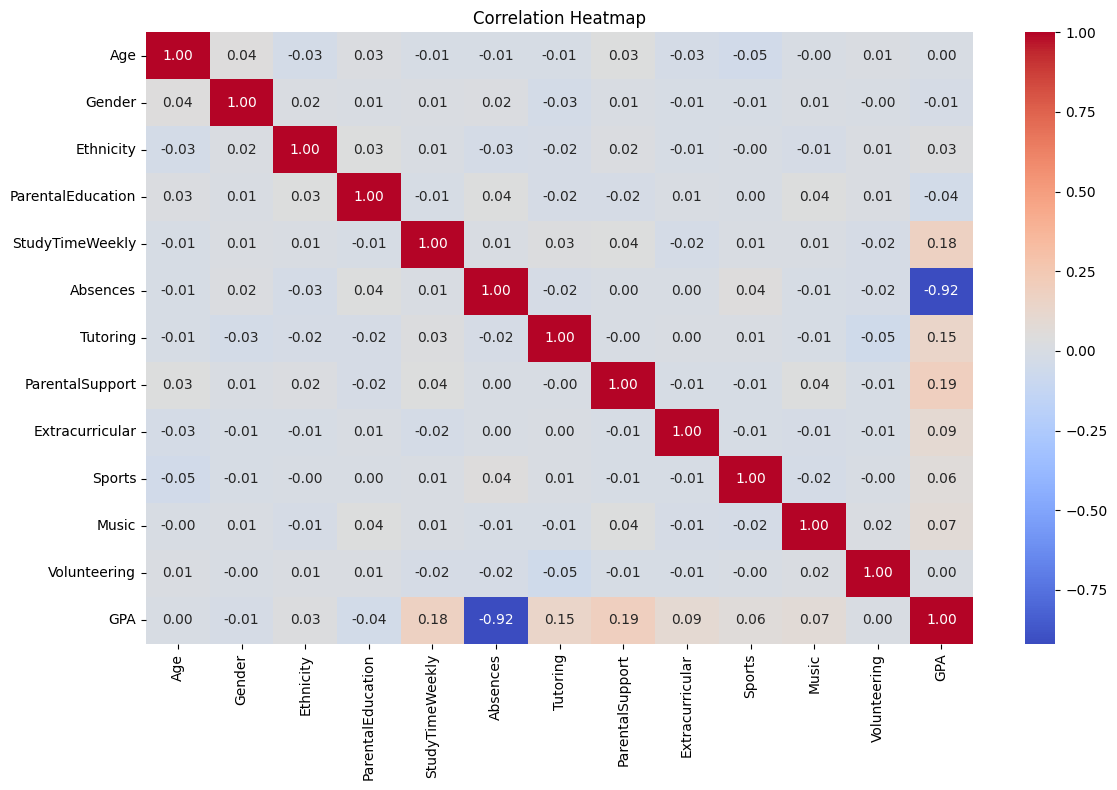

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


<a id="22"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📉 Scatter Plot: Study Time vs GPA
</h2>

A scatter plot helps visualize the relationship between weekly study time and GPA.


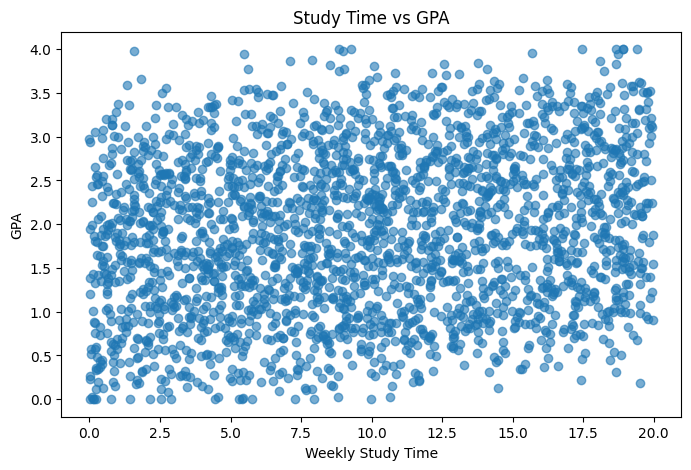

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(df["StudyTimeWeekly"], df["GPA"], alpha=0.6)
plt.xlabel("Weekly Study Time")
plt.ylabel("GPA")
plt.title("Study Time vs GPA")
plt.show()


<a id="24"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🤖 Regression Models
</h2>

Ten regression algorithms are trained and compared: Linear Regression, Ridge, Lasso, ElasticNet, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, KNN, and SVR. The target variable is continuous GPA.


In [13]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR


<a id="26"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🧪 Training and Evaluating All Regression Models
</h2>

Each model is trained on the training data and evaluated on the test data. We use **MAE, MSE, RMSE, and R²** because these are standard regression evaluation metrics. For R², a value closer to 1 indicates that the model explains more of the variation in the target on this test set; MAE, MSE, and RMSE are error measures where lower values indicate smaller prediction errors.


In [14]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=101),
    "Decision Tree": DecisionTreeRegressor(random_state=101),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=101),
    "Gradient Boosting": GradientBoostingRegressor(random_state=101),
    "AdaBoost": AdaBoostRegressor(random_state=101, n_estimators=100),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR": SVR(kernel="rbf")
}

results = []

for name, model in models.items():
    model.fit(X_train_fit, y_train)
    pred = model.predict(X_test_fit)

    mae = mean_absolute_error(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE", "MSE", "RMSE", "R2 Score"]
)

results_df.sort_values("R2 Score", ascending=False)


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.164969,0.041562,0.203867,0.951838
1,Ridge Regression,0.164980,0.041581,0.203914,0.951816
3,ElasticNet,0.165243,0.042138,0.205275,0.951171
2,Lasso Regression,0.166192,0.042670,0.206567,0.950554
6,Gradient Boosting,0.170011,0.045862,0.214153,0.946856
9,SVR,0.189138,0.055904,0.236440,0.935219
5,Random Forest,0.200493,0.062264,0.249527,0.927849
7,AdaBoost,0.205391,0.065767,0.256452,0.923789
4,Decision Tree,0.289369,0.130343,0.361030,0.848959
8,KNN,0.377941,0.220298,0.469359,0.744720


<a id="28"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📊 Regression Model Comparison
</h2>

The following table compares the performance of all regression models using MAE, MSE, RMSE, and R² score. The results are based on the actual train-test split and should be reported exactly as produced by the notebook.


In [15]:
results_df = results_df.sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.164969,0.041562,0.203867,0.951838
1,Ridge Regression,0.164980,0.041581,0.203914,0.951816
2,ElasticNet,0.165243,0.042138,0.205275,0.951171
3,Lasso Regression,0.166192,0.042670,0.206567,0.950554
4,Gradient Boosting,0.170011,0.045862,0.214153,0.946856
5,SVR,0.189138,0.055904,0.236440,0.935219
6,Random Forest,0.200493,0.062264,0.249527,0.927849
7,AdaBoost,0.205391,0.065767,0.256452,0.923789
8,Decision Tree,0.289369,0.130343,0.361030,0.848959
9,KNN,0.377941,0.220298,0.469359,0.744720


<a id="30"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📊 Graph for All Regression Models
</h2>

A bar chart is created to visually compare the R² score of all regression models.


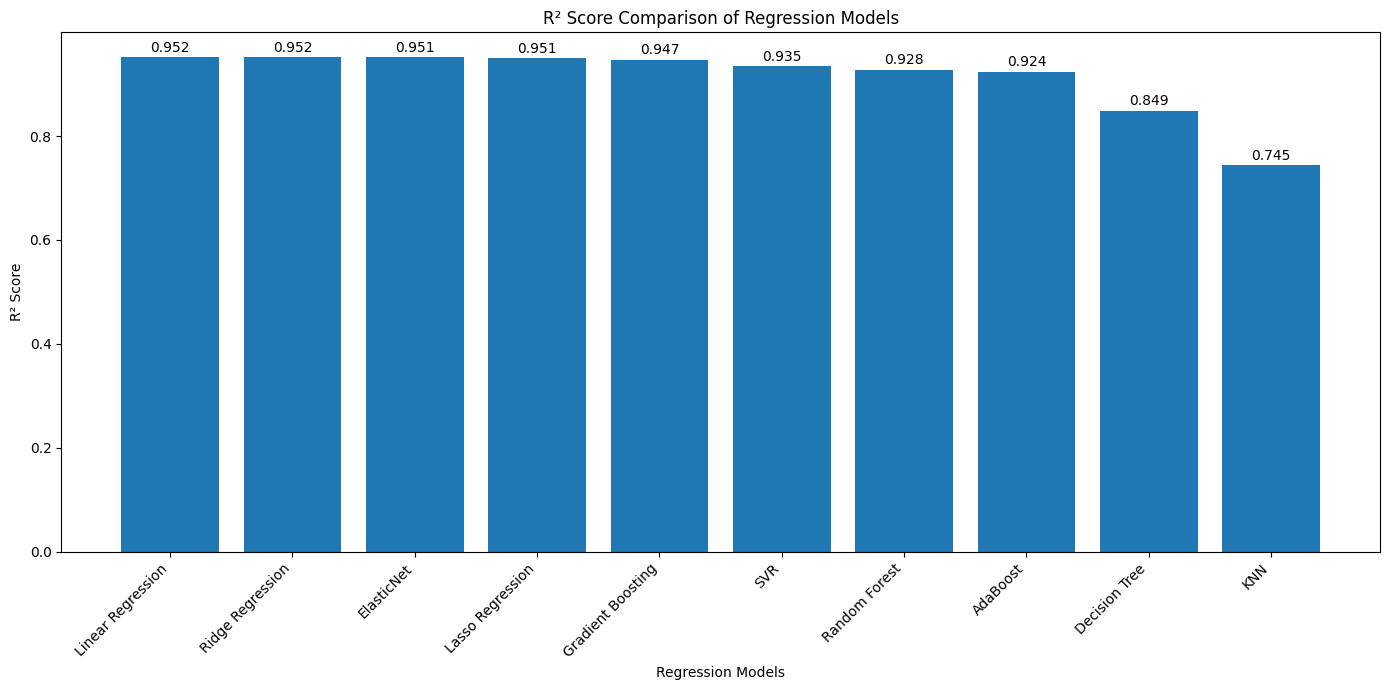

In [16]:
plt.figure(figsize=(14, 7))
bars = plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.title("R² Score Comparison of Regression Models")
plt.xticks(rotation=45, ha="right")

for bar, value in zip(bars, results_df["R2 Score"]):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()


<a id="32"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🌲 Selecting Random Forest for Deployment
</h2>

Random Forest Regressor is used for deployment in this project. It combines multiple decision trees and averages their predictions to produce a continuous GPA prediction.


In [17]:
model_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=101
)

model_rf.fit(X_train_fit, y_train)

rf_pred = model_rf.predict(X_test_fit)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE  :: {rf_mae:.4f}")
print(f"Random Forest MSE  :: {rf_mse:.4f}")
print(f"Random Forest RMSE :: {rf_rmse:.4f}")
print(f"Random Forest R²   :: {rf_r2:.4f}")


Random Forest MAE  :: 0.2005
Random Forest MSE  :: 0.0623
Random Forest RMSE :: 0.2495
Random Forest R²   :: 0.9278


<a id="34"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
📌 Actual vs Predicted GPA
</h2>

This graph compares the actual GPA values with the GPA values predicted by the Random Forest model. Points closer to a straight diagonal relationship indicate closer agreement between actual and predicted values.


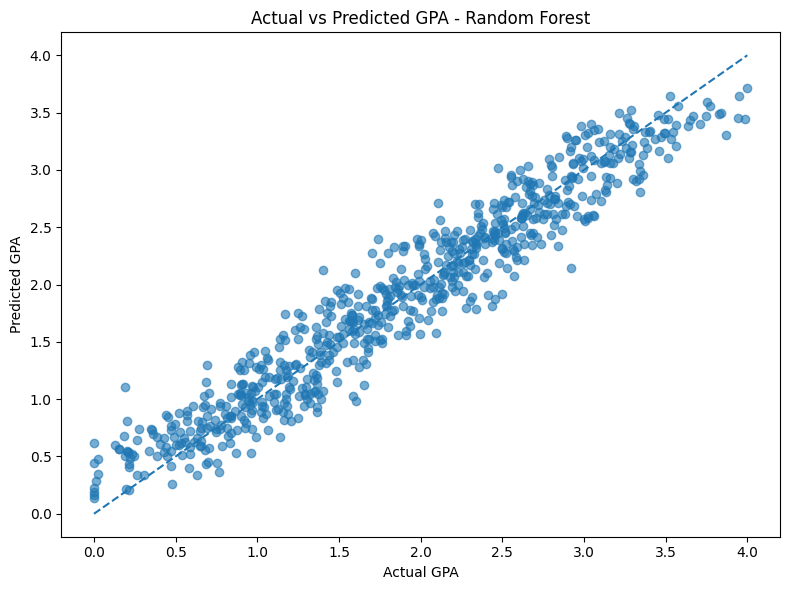

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_pred, alpha=0.6)
plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Actual vs Predicted GPA - Random Forest")

min_val = min(y_test.min(), rf_pred.min())
max_val = max(y_test.max(), rf_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.tight_layout()
plt.show()


<a id="36"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
💾 Saving the Trained Model and Scaler
</h2>

After training the Random Forest Regressor, the trained model is saved using Python's `pickle` module. The fitted StandardScaler is also saved. These files can later be loaded by the Streamlit application without retraining the model.


In [19]:
import pickle

with open("model_regression.pkl", "wb") as file:
    pickle.dump(model_rf, file)

with open("scaler_regression.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("Random Forest regression model and scaler saved successfully!")


Random Forest regression model and scaler saved successfully!


<a id="38"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🚀 Streamlit Deployment
</h2>

The trained regression model can be deployed using Streamlit. The application accepts student information as input, applies the saved scaler, and predicts the student's GPA.


<a id="39"></a>
<h2 style="background-color:#6C5CE7; color:white; padding:12px 20px; border-radius:10px; border-left:8px solid #4834D4; font-family:Arial;">
🙏 Thank You
</h2>

Thank you for reviewing the **Student GPA Regression Analysis and Prediction** project. The project demonstrates data preprocessing, exploratory data analysis, regression modeling, model evaluation, comparison, and deployment.
